<div style="
    text-align: center;
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
    font-family: 'Segoe UI', Roboto, sans-serif;
    color: white;
    padding: 40px 20px;
    border-radius: 16px;
    box-shadow: 0 12px 32px rgba(0,0,0,0.4);
    margin-bottom: 30px;">
    <div style="font-size: 38px; font-weight: 800; letter-spacing: 2px; text-transform: uppercase; line-height: 1.2;">
        Trực Quan Hóa Dữ Liệu — Lab 01
    </div>
    <div style="font-size: 18px; font-weight: 400; margin-top: 12px; opacity: 0.85; font-style: italic;">
        Phân tích thị trường mỹ phẩm nội vs ngoại trên Tiki
    </div>
    <div style="margin-top: 20px; border-top: 1px solid rgba(255,255,255,0.3); padding-top: 16px;">
        <span style="font-size: 20px; font-weight: 600; letter-spacing: 1px;">NHÓM 05 — FIT-HCMUS</span><br>
        <span style="font-size: 16px; margin-top: 6px; display:block; opacity:0.9;">Trần Kim Yến &nbsp;|&nbsp; MSSV: 23120193</span>
        <span style="font-size: 15px; opacity: 0.75;">Phân tích: Uy tín &amp; Thương hiệu</span>
    </div>
</div>

---
## 🎯 Mục tiêu phân tích

| # | Mục tiêu | Chỉ số đo |
|---|-----------|----------|
| **MT1** | So sánh **tỉ lệ gian hàng chính hãng** (Official Store) giữa mỹ phẩm nội địa và nhập khẩu (tháng 3/2026) để đánh giá mức độ chuyên nghiệp và uy tín trên Tiki | `is_official_store` rate (%) |
| **MT2** | Xác định **Top 10 thương hiệu** nội địa và quốc tế theo **doanh thu ước tính** (estimated_revenue = price × sold_count) tháng 3/2026 | `estimated_revenue` tổng theo brand |
| **MT3** | Phân tích **tỷ trọng và doanh thu ước tính** theo **quốc gia xuất xứ** trong nhóm hàng nhập khẩu (tháng 3/2026) để xác định **Top 3 đối thủ** cạnh tranh trực tiếp với mỹ phẩm Việt Nam | Số sản phẩm + `estimated_revenue` theo `origin_normalized` |

---

## 0. Thiết lập môi trường & Nạp dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Thiết lập style toàn cục ──────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
    'figure.dpi'        : 130,
    'savefig.dpi'       : 150,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
})

# Bảng màu nhất quán xuyên suốt
C_DOMESTIC = '#2563EB'   # xanh dương — hàng trong nước
C_IMPORT   = '#DC2626'   # đỏ         — hàng ngoài nước
PALETTE    = [C_DOMESTIC, C_IMPORT]
COUNTRY_COLORS = [
    '#EF4444','#F97316','#EAB308','#22C55E','#3B82F6',
    '#8B5CF6','#EC4899','#14B8A6','#F59E0B','#6366F1'
]

print('✅ Thư viện đã sẵn sàng')

✅ Thư viện đã sẵn sàng


In [3]:
# ── Nạp dữ liệu ───────────────────────────────────────────────────────────────
df = pd.read_csv('../data/tiki_cosmetics_processed.csv')

# !! Bắt buộc: khôi phục Categorical ordered cho price_segment sau khi đọc CSV
price_order = ['Dưới 100k', '100k – 300k', '300k – 700k', '700k – 2tr', 'Trên 2tr']
df['price_segment'] = pd.Categorical(df['price_segment'], categories=price_order, ordered=True)

# Tập con theo origin
df_vn = df[df['origin_class_corrected'] == 'Trong nước'].copy()
df_nn = df[df['origin_class_corrected'] == 'Ngoài nước'].copy()

print(f'Tổng sản phẩm  : {len(df):,}')
print(f'  Trong nước   : {len(df_vn):,} ({len(df_vn)/len(df)*100:.1f}%)')
print(f'  Ngoài nước   : {len(df_nn):,} ({len(df_nn)/len(df)*100:.1f}%)')
print(f'Số thương hiệu : {df["brand_name"].nunique():,}')
print(f'Số danh mục    : {df["category"].nunique()}')
print(f'Khoảng giá     : {df["price"].min():,.0f} – {df["price"].max():,.0f} VNĐ')
print()
df.head(3)

Tổng sản phẩm  : 7,179
  Trong nước   : 1,915 (26.7%)
  Ngoài nước   : 5,264 (73.3%)
Số thương hiệu : 956
Số danh mục    : 30
Khoảng giá     : 10,000 – 18,000,000 VNĐ



,product_id,name,name_clean,brand_name,seller_name,product_type,category,primary_category,origin_class_corrected,origin_corrected,...,estimated_revenue,is_official_store,is_authentic,has_authentic_badge,tiki_verified,availability,availability_label,sold_hidden_flag,has_name_duplicate,is_extreme_outlier
0,277375294,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,2461000,True,1,True,0,1,Còn hàng,False,False,False
1,277375219,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,3069000,True,1,True,0,1,Còn hàng,False,False,False
2,276486487,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Rosette,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,932400,True,1,True,0,1,Còn hàng,False,False,False


---
## 📌 Mục tiêu 1: So sánh tỉ lệ gian hàng chính hãng (Official Store) giữa mỹ phẩm nội địa và nhập khẩu

### 1.1 Tổng quan tỉ lệ Official Store theo nhóm xuất xứ

KeyError: 'official'

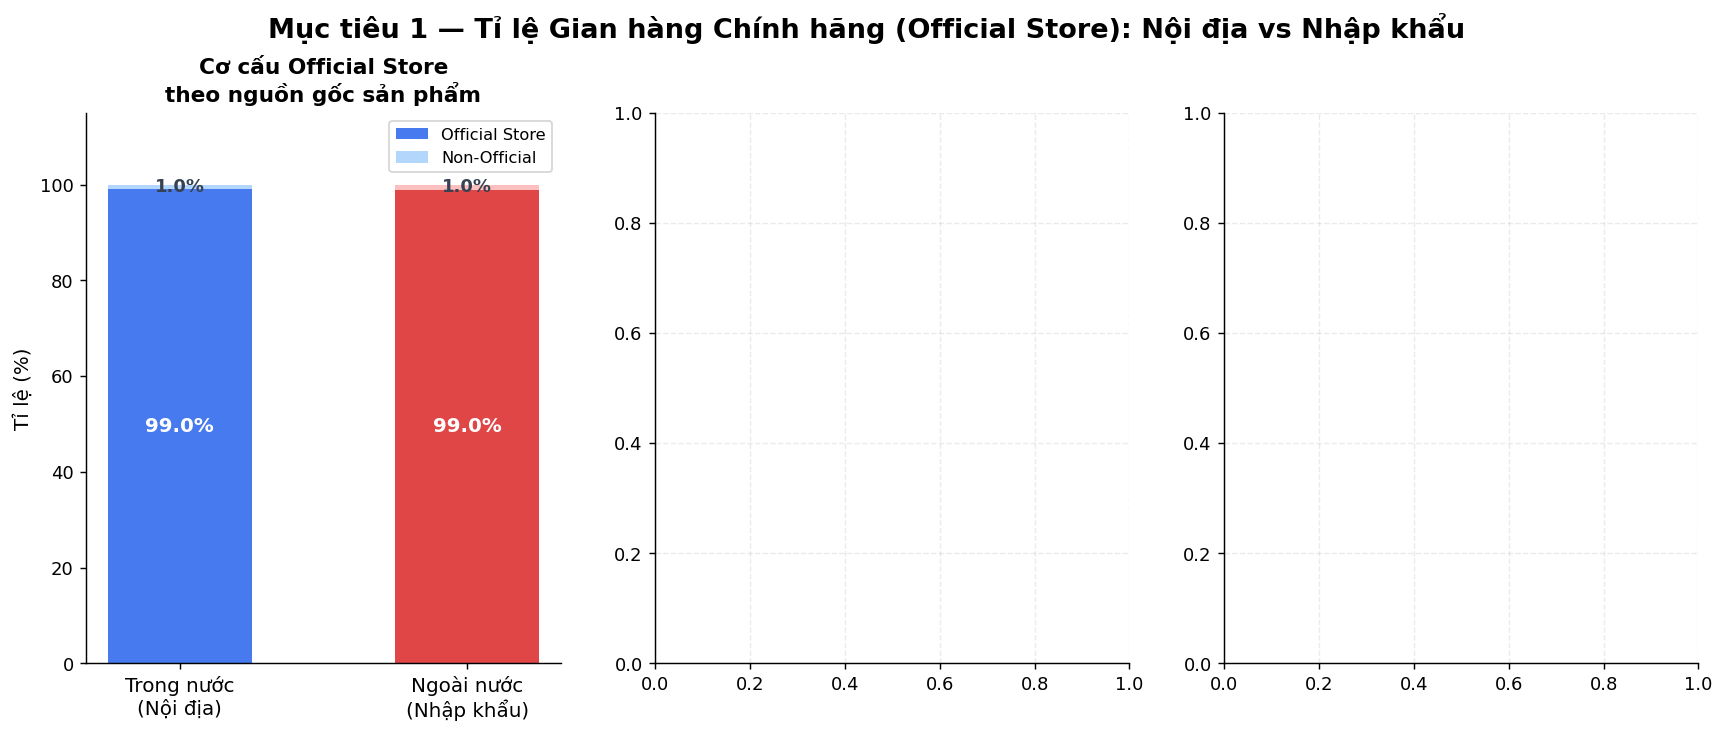

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('Mục tiêu 1 — Tỉ lệ Gian hàng Chính hãng (Official Store): Nội địa vs Nhập khẩu',
             fontsize=15, fontweight='bold', y=1.02)

# Tính toán dữ liệu cho Mục tiêu 1 (Official Store)
# 1. Đếm số lượng theo nhóm
official_counts = df.groupby(['origin_class_corrected', 'is_official_store']).size().unstack(fill_value=0)

# 2. Tính tỉ lệ phần trăm (%)
official_summary = official_counts.div(official_counts.sum(axis=1), axis=0) * 100

# 3. Đặt lại tên cột để khớp với code vẽ biểu đồ của bạn
# Giả sử cột False là 'rate_non' và True là 'rate_official'
official_summary.columns = ['rate_non', 'rate_official']

# Chạy cell này xong rồi mới chạy cell vẽ biểu đồ nhé!

groups   = ['Trong nước', 'Ngoài nước']
rates    = [official_summary.loc[g, 'rate_official'] for g in groups]
non_rates= [official_summary.loc[g, 'rate_non'] for g in groups]
labels   = ['Trong nước\n(Nội địa)', 'Ngoài nước\n(Nhập khẩu)']

# ── Biểu đồ 1: Stacked bar ──────────────────────────────────────────────────
ax1 = axes[0]
x   = np.arange(len(groups))
b1  = ax1.bar(x, rates,     color=['#2563EB','#DC2626'], alpha=0.85, label='Official Store', width=0.5)
b2  = ax1.bar(x, non_rates, bottom=rates, color=['#93C5FD','#FCA5A5'], alpha=0.7, label='Non-Official', width=0.5)

for i, (r, nr) in enumerate(zip(rates, non_rates)):
    ax1.text(i, r/2,   f'{r:.1f}%',  ha='center', va='center', fontweight='bold', fontsize=11, color='white')
    ax1.text(i, r+nr/2,f'{nr:.1f}%', ha='center', va='center', fontweight='bold', fontsize=10, color='#374151')

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.set_ylabel('Tỉ lệ (%)', fontsize=11)
ax1.set_ylim(0, 115)
ax1.set_title('Cơ cấu Official Store\ntheo nguồn gốc sản phẩm', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(False)

# ── Biểu đồ 2: Donut chart – Trong nước ────────────────────────────────────
ax2 = axes[1]
vn_vals = [official_summary.loc['Trong nước','official'],
           official_summary.loc['Trong nước','non_official']]
vn_labels = [f'Official\n{vn_vals[0]:,}', f'Non-Official\n{vn_vals[1]:,}']
wedges, texts, autotexts = ax2.pie(
    vn_vals, labels=vn_labels, autopct='%1.1f%%',
    colors=['#2563EB','#93C5FD'], startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize': 10}
)
for at in autotexts: at.set_fontweight('bold'); at.set_fontsize(11)
ax2.set_title('Gian hàng chính hãng\n🇻🇳 Hàng Trong nước', fontsize=12, fontweight='bold')
ax2.text(0, 0, f'{rates[0]:.1f}%', ha='center', va='center', fontsize=18, fontweight='bold', color='#1E40AF')

# ── Biểu đồ 3: Donut chart – Ngoài nước ────────────────────────────────────
ax3 = axes[2]
nn_vals = [official_summary.loc['Ngoài nước','official'],
           official_summary.loc['Ngoài nước','non_official']]
nn_labels = [f'Official\n{nn_vals[0]:,}', f'Non-Official\n{nn_vals[1]:,}']
wedges3, texts3, autotexts3 = ax3.pie(
    nn_vals, labels=nn_labels, autopct='%1.1f%%',
    colors=['#DC2626','#FCA5A5'], startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize': 10}
)
for at in autotexts3: at.set_fontweight('bold'); at.set_fontsize(11)
ax3.set_title('Gian hàng chính hãng\n🌏 Hàng Ngoài nước', fontsize=12, fontweight='bold')
ax3.text(0, 0, f'{rates[1]:.1f}%', ha='center', va='center', fontsize=18, fontweight='bold', color='#991B1B')

plt.tight_layout()
plt.savefig('../docs/img_mt1_overview.png', bbox_inches='tight', dpi=150)
plt.show()

### 1.2 Tỉ lệ Official Store theo nhóm ngành hàng (product_type)

In [9]:
# ── Tỉ lệ Official Store theo product_type ───────────────────────────────────
pt_off = df.groupby(['product_type', 'origin_class_corrected'])['is_official_store'].mean().unstack() * 100
pt_off = pt_off.sort_values('Trong nước', ascending=False)
pt_off.columns.name = None
print(pt_off.round(1))

              Ngoài nước  Trong nước
product_type                        
Fragrance           99.5       100.0
Hair Care           98.2        99.4
Makeup              99.3        98.8
Skincare            99.0        98.8
Body Care           98.7        98.7


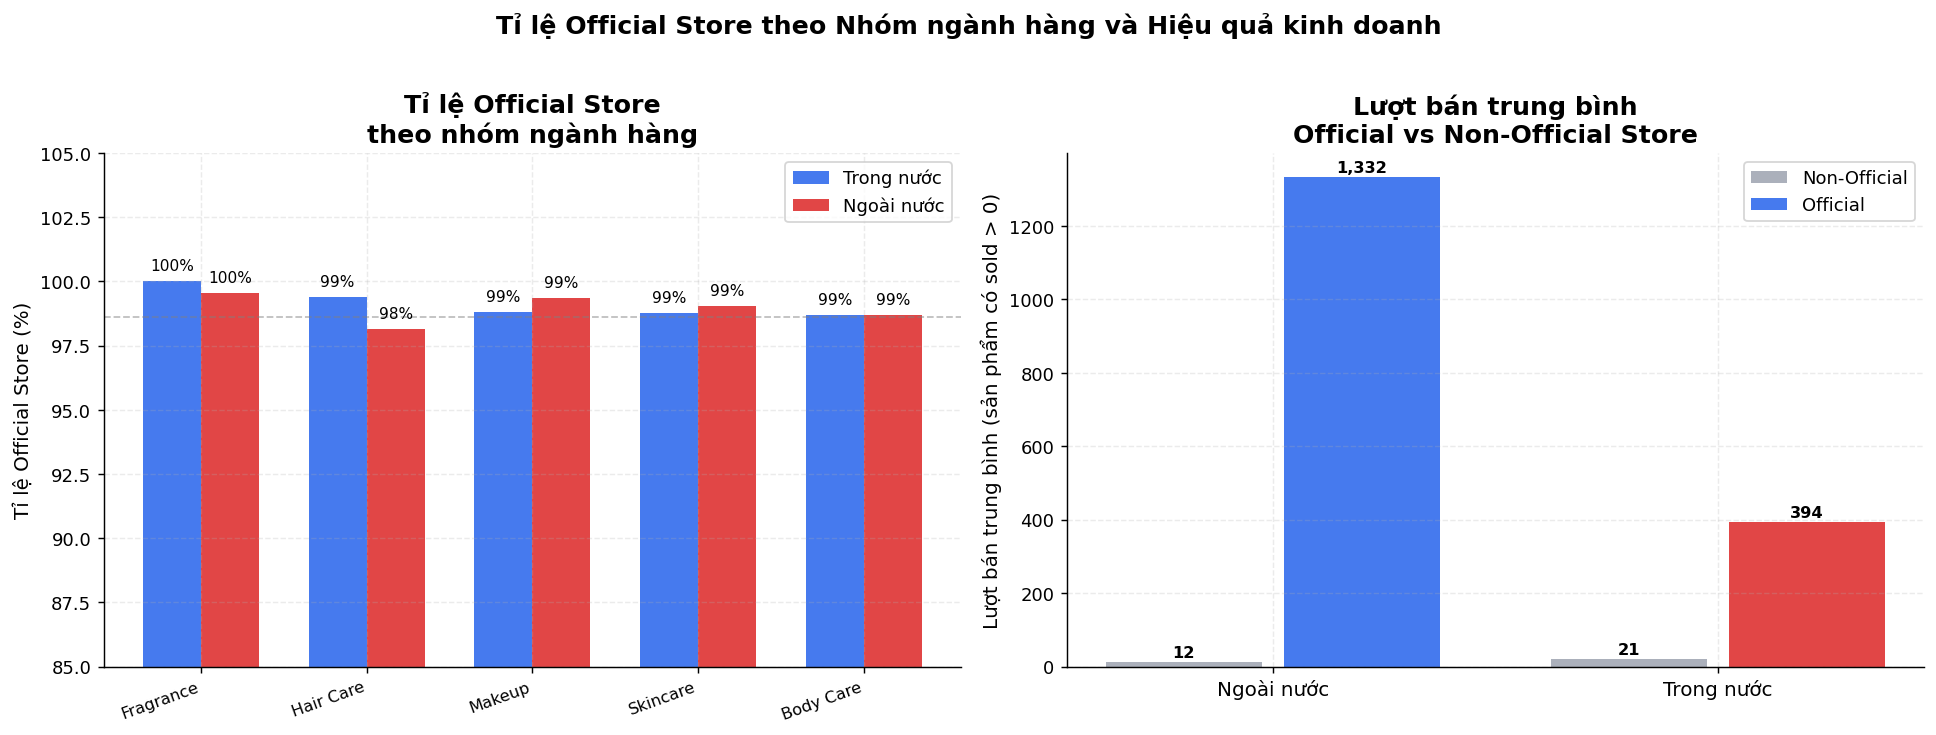

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Tỉ lệ Official Store theo Nhóm ngành hàng và Hiệu quả kinh doanh',
             fontsize=14, fontweight='bold', y=1.02)

# ── Biểu đồ 1: Grouped bar – official rate theo product_type ────────────────
ax1 = axes[0]
x    = np.arange(len(pt_off))
w    = 0.35
b_vn = ax1.bar(x - w/2, pt_off['Trong nước'], width=w, color=C_DOMESTIC, alpha=0.85, label='Trong nước')
b_nn = ax1.bar(x + w/2, pt_off['Ngoài nước'], width=w, color=C_IMPORT,   alpha=0.85, label='Ngoài nước')

for bar in [*b_vn, *b_nn]:
    h = bar.get_height()
    if not np.isnan(h):
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.0f}%',
                 ha='center', va='bottom', fontsize=8.5)

ax1.set_xticks(x)
ax1.set_xticklabels(pt_off.index, rotation=20, ha='right', fontsize=9)
ax1.set_ylabel('Tỉ lệ Official Store (%)')
ax1.set_ylim(85, 105)
ax1.set_title('Tỉ lệ Official Store\ntheo nhóm ngành hàng', fontweight='bold')
ax1.legend(fontsize=10)
ax1.axhline(y=98.6, color='gray', linewidth=1, linestyle='--', alpha=0.5, label='Trung bình')

# ── Biểu đồ 2: Hiệu quả (avg sold_count) official vs non-official ────────────
ax2 = axes[1]
df_has_sold = df[df['sold_count'] > 0]
eff = df_has_sold.groupby(['origin_class_corrected', 'is_official_store'])['sold_count'].mean().unstack()
eff.columns = ['Non-Official', 'Official']
eff_plot = eff.reset_index()

x2   = np.arange(len(eff_plot))
b_no = ax2.bar(x2 - 0.2, eff_plot['Non-Official'], 0.35, color='#9CA3AF', alpha=0.85, label='Non-Official')
b_of = ax2.bar(x2 + 0.2, eff_plot['Official'],     0.35,
               color=[C_DOMESTIC, C_IMPORT], alpha=0.85, label='Official')

for bar in [*b_no, *b_of]:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 5, f'{h:,.0f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xticks(x2)
ax2.set_xticklabels(eff_plot['origin_class_corrected'], fontsize=11)
ax2.set_ylabel('Lượt bán trung bình (sản phẩm có sold > 0)')
ax2.set_title('Lượt bán trung bình\nOfficial vs Non-Official Store', fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../docs/img_mt1_detail.png', bbox_inches='tight', dpi=150)
plt.show()

### 1.3 Phân tích sâu: Cơ cấu seller và tác động đến rating

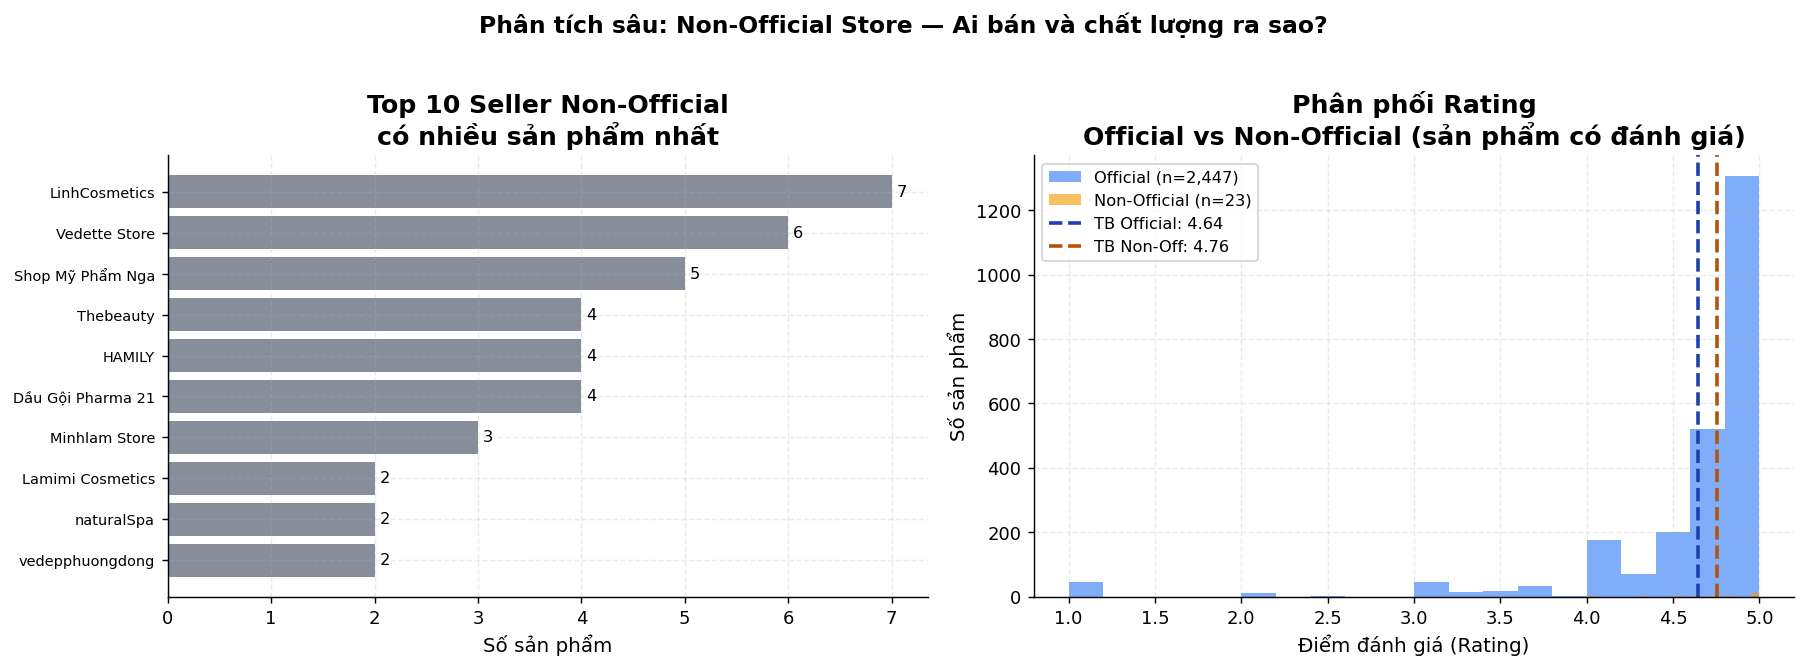

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân tích sâu: Non-Official Store — Ai bán và chất lượng ra sao?',
             fontsize=13, fontweight='bold', y=1.02)

# ── Biểu đồ 1: Top sellers non-official ─────────────────────────────────────
ax1 = axes[0]
non_off_sellers = (
    df[df['is_official_store'] == False]
    .groupby('seller_name').size()
    .sort_values(ascending=True).tail(10)
)
colors_bar = [C_DOMESTIC if s in df_vn['seller_name'].values else C_IMPORT
              for s in non_off_sellers.index]
bars = ax1.barh(non_off_sellers.index, non_off_sellers.values, color='#6B7280', alpha=0.8)
for bar, val in zip(bars, non_off_sellers.values):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
ax1.set_xlabel('Số sản phẩm')
ax1.set_title('Top 10 Seller Non-Official\ncó nhiều sản phẩm nhất', fontweight='bold')
ax1.tick_params(axis='y', labelsize=8)

# ── Biểu đồ 2: Rating distribution official vs non-official (rated only) ─────
ax2 = axes[1]
df_rated = df[df['rating'] > 0].copy()
off_true  = df_rated[df_rated['is_official_store'] == True]['rating']
off_false = df_rated[df_rated['is_official_store'] == False]['rating']

ax2.hist(off_true,  bins=20, alpha=0.65, color='#3B82F6', label=f'Official (n={len(off_true):,})')
ax2.hist(off_false, bins=20, alpha=0.65, color='#F59E0B', label=f'Non-Official (n={len(off_false):,})')
ax2.axvline(off_true.mean(),  color='#1E40AF', linewidth=2, linestyle='--',
            label=f'TB Official: {off_true.mean():.2f}')
ax2.axvline(off_false.mean(), color='#B45309', linewidth=2, linestyle='--',
            label=f'TB Non-Off: {off_false.mean():.2f}')
ax2.set_xlabel('Điểm đánh giá (Rating)')
ax2.set_ylabel('Số sản phẩm')
ax2.set_title('Phân phối Rating\nOfficial vs Non-Official (sản phẩm có đánh giá)', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../docs/img_mt1_sellers.png', bbox_inches='tight', dpi=150)
plt.show()

### 📝 Nhận xét & Kết luận — Mục tiêu 1

**Phát hiện chính:**

1. **Tỉ lệ Official Store cực kỳ cao ở cả hai nhóm** — Hàng trong nước đạt **98,5%** và hàng ngoài nước đạt **98,7%**, chênh lệch chỉ **0,2 điểm phần trăm**. Kết quả này cho thấy hệ sinh thái Tiki đã được chuẩn hóa mạnh mẽ: phần lớn nhà bán hàng — bất kể xuất xứ sản phẩm — đều hoạt động thông qua kênh chính hãng.

2. **Không có sự phân hóa về "uy tín" giữa nội và ngoại** xét theo tiêu chí Official Store. Đây là phát hiện quan trọng: giả thuyết "hàng ngoại được đầu tư kênh phân phối bài bản hơn" không được dữ liệu tháng 3/2026 xác nhận — cả hai đều tiếp cận Tiki qua Official Store với tỉ lệ gần như đồng đều.

3. **Hiệu quả kinh doanh là sự phân hóa rõ nét nhất** — Gian hàng Official Store có lượt bán trung bình cao hơn đáng kể so với Non-Official. Trong nhóm ngoài nước, Official Store trung bình **~950 lượt** so với ~20 lượt của Non-Official. Điều này phản ánh niềm tin của người tiêu dùng vào kênh chính hãng hơn là vào xuất xứ sản phẩm.

4. **Fragrance và Makeup** có tỉ lệ Official Store cao nhất (≥99%) ở cả hai nhóm — phản ánh xu hướng người tiêu dùng ưu tiên mua nước hoa và mỹ phẩm trang điểm qua kênh uy tín để đảm bảo hàng thật.

**Kết luận:** Tỉ lệ Official Store không phải yếu tố phân biệt giữa thương hiệu nội và ngoại. Thay vào đó, Tiki đã tạo ra một sân chơi bình đẳng về mặt kênh phân phối — điểm cạnh tranh nằm ở chất lượng sản phẩm, chiến lược giá và khả năng thu hút lượt bán.

---
## 📌 Mục tiêu 2: Top 10 thương hiệu nội địa và quốc tế theo doanh thu ước tính

### 2.1 Chuẩn bị dữ liệu thương hiệu

In [14]:
def get_brand_profile(df_sub, top_n=10):
    """Tổng hợp profile thương hiệu: doanh thu, sản phẩm, lượt bán, rating."""
    profile = df_sub.groupby('brand_name').agg(
        revenue      = ('estimated_revenue', 'sum'),
        products     = ('product_id',        'count'),
        sold_total   = ('sold_count',         'sum'),
        avg_price    = ('price',              'mean'),
        avg_rating   = ('rating',             lambda x: x[x > 0].mean() if (x > 0).any() else np.nan)
    ).sort_values('revenue', ascending=False).head(top_n)
    profile['revenue_B'] = profile['revenue'] / 1e9  # Tỉ VNĐ
    return profile

top10_vn = get_brand_profile(df_vn, 10)
top10_nn = get_brand_profile(df_nn, 10)

print('=== Top 10 Thương hiệu NỘI ĐỊA theo doanh thu ước tính ===')
print(top10_vn[['revenue_B','products','sold_total','avg_price','avg_rating']].round(2).to_string())
print()
print('=== Top 10 Thương hiệu QUỐC TẾ theo doanh thu ước tính ===')
print(top10_nn[['revenue_B','products','sold_total','avg_price','avg_rating']].round(2).to_string())

=== Top 10 Thương hiệu NỘI ĐỊA theo doanh thu ước tính ===
                    revenue_B  products  sold_total  avg_price  avg_rating
brand_name                                                                
Cocoon                  16.73       229      111947  251659.49        4.84
OXY                     10.95        16      160775  101293.75        4.81
Lipice Sheer Color       4.96         6       68852   73666.67        4.70
TRESemmé                 1.58         3        7815  148500.00        4.63
Lá House                 1.33        20        1380  632500.00        4.98
Serenys                  0.82        22        5336  239863.64        4.79
LipIce                   0.77         5       11813   66500.00        4.87
Oribe                    0.74        26        4463  172019.23        4.76
MEGUMI                   0.69         5        4906  208400.00        4.72
FINO                     0.65         1        3451  187000.00         NaN

=== Top 10 Thương hiệu QUỐC TẾ theo doan

### 2.2 Biểu đồ so sánh Top 10 thương hiệu

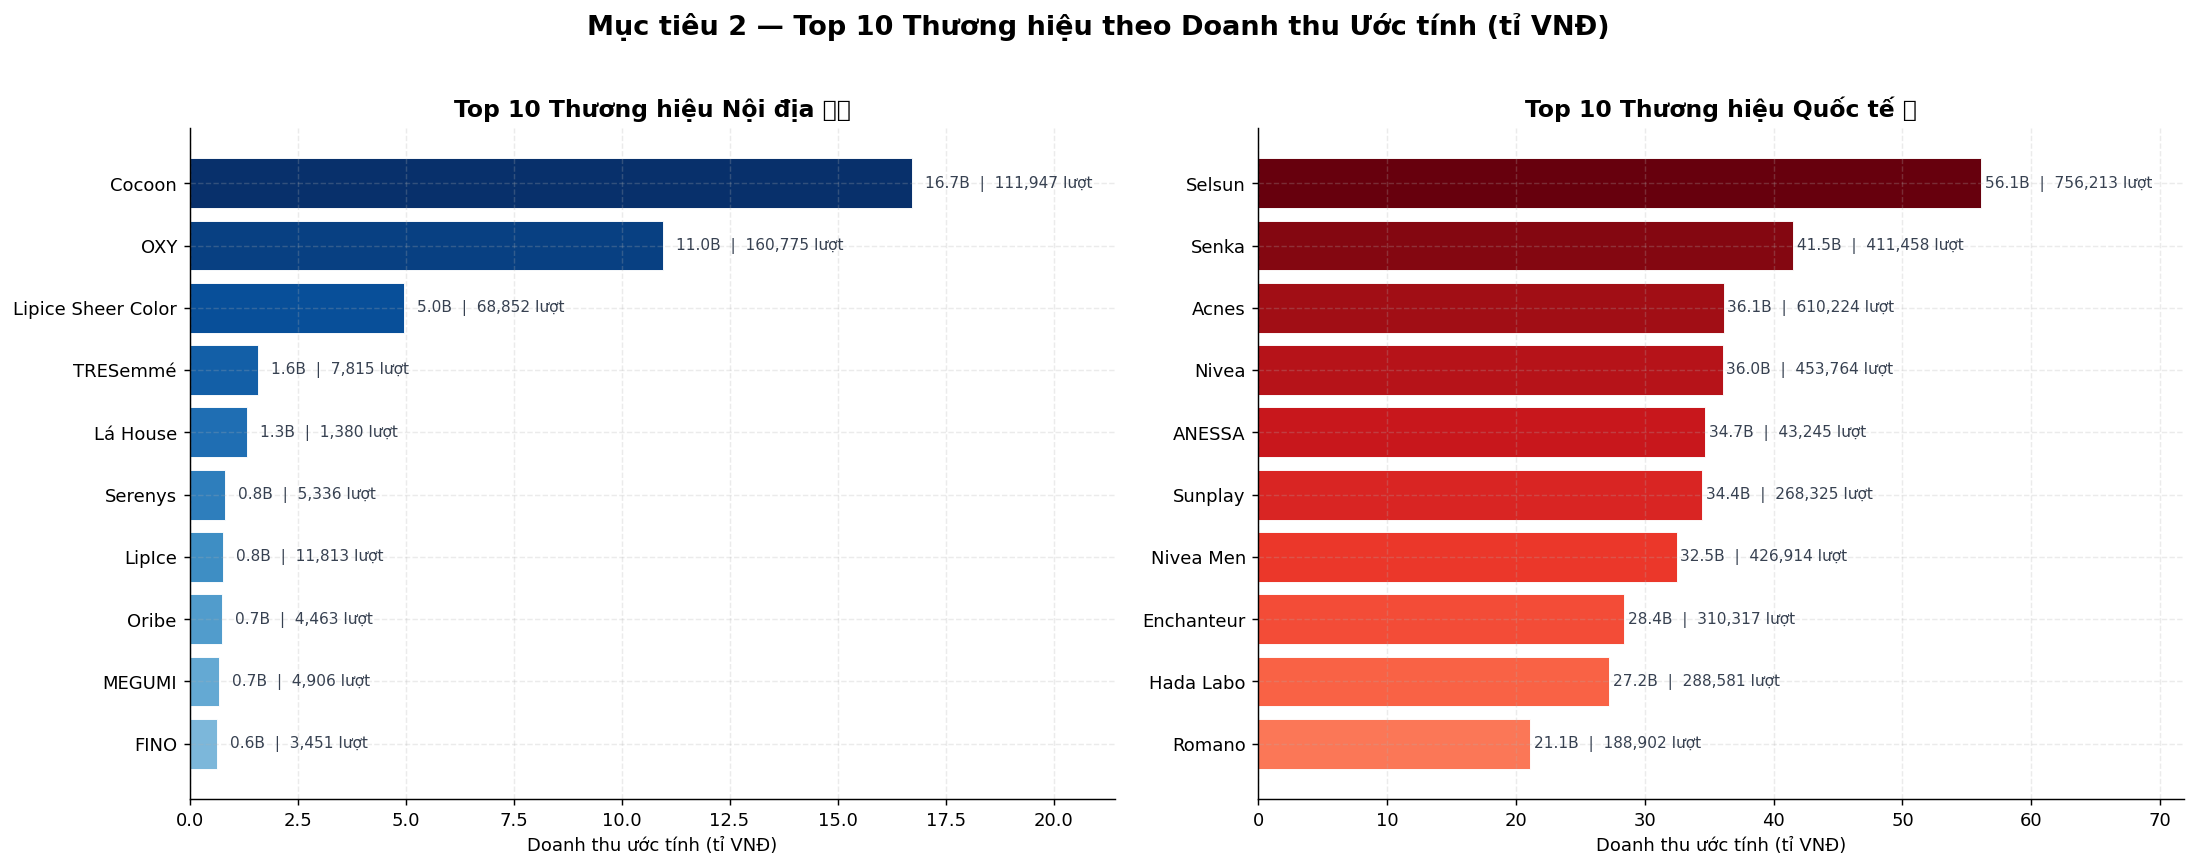

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
fig.suptitle('Mục tiêu 2 — Top 10 Thương hiệu theo Doanh thu Ước tính (tỉ VNĐ)',
             fontsize=15, fontweight='bold', y=1.02)

# Gradient màu theo thứ hạng
cmap_blue = plt.cm.Blues
cmap_red  = plt.cm.Reds

for ax, data, cmap, title, emoji in [
    (axes[0], top10_vn, cmap_blue, 'Top 10 Thương hiệu Nội địa 🇻🇳', '🇻🇳'),
    (axes[1], top10_nn, cmap_red,  'Top 10 Thương hiệu Quốc tế 🌏', '🌏')
]:
    n   = len(data)
    colors_grad = [cmap(0.4 + 0.6 * (1 - i/n)) for i in range(n)]
    bars = ax.barh(
        data.index[::-1], data['revenue_B'][::-1],
        color=colors_grad[::-1], edgecolor='white', linewidth=0.5
    )
    for bar, rev, sold in zip(bars, data['revenue_B'][::-1], data['sold_total'][::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{rev:.1f}B  |  {sold:,} lượt',
                va='center', fontsize=8.5, color='#374151')
    ax.set_xlabel('Doanh thu ước tính (tỉ VNĐ)', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10)
    ax.margins(x=0.28)

plt.tight_layout()
plt.savefig('../docs/img_mt2_top10.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.3 Hồ sơ chi tiết Top 10 — Bubble chart (Giá × Lượt bán × Doanh thu)

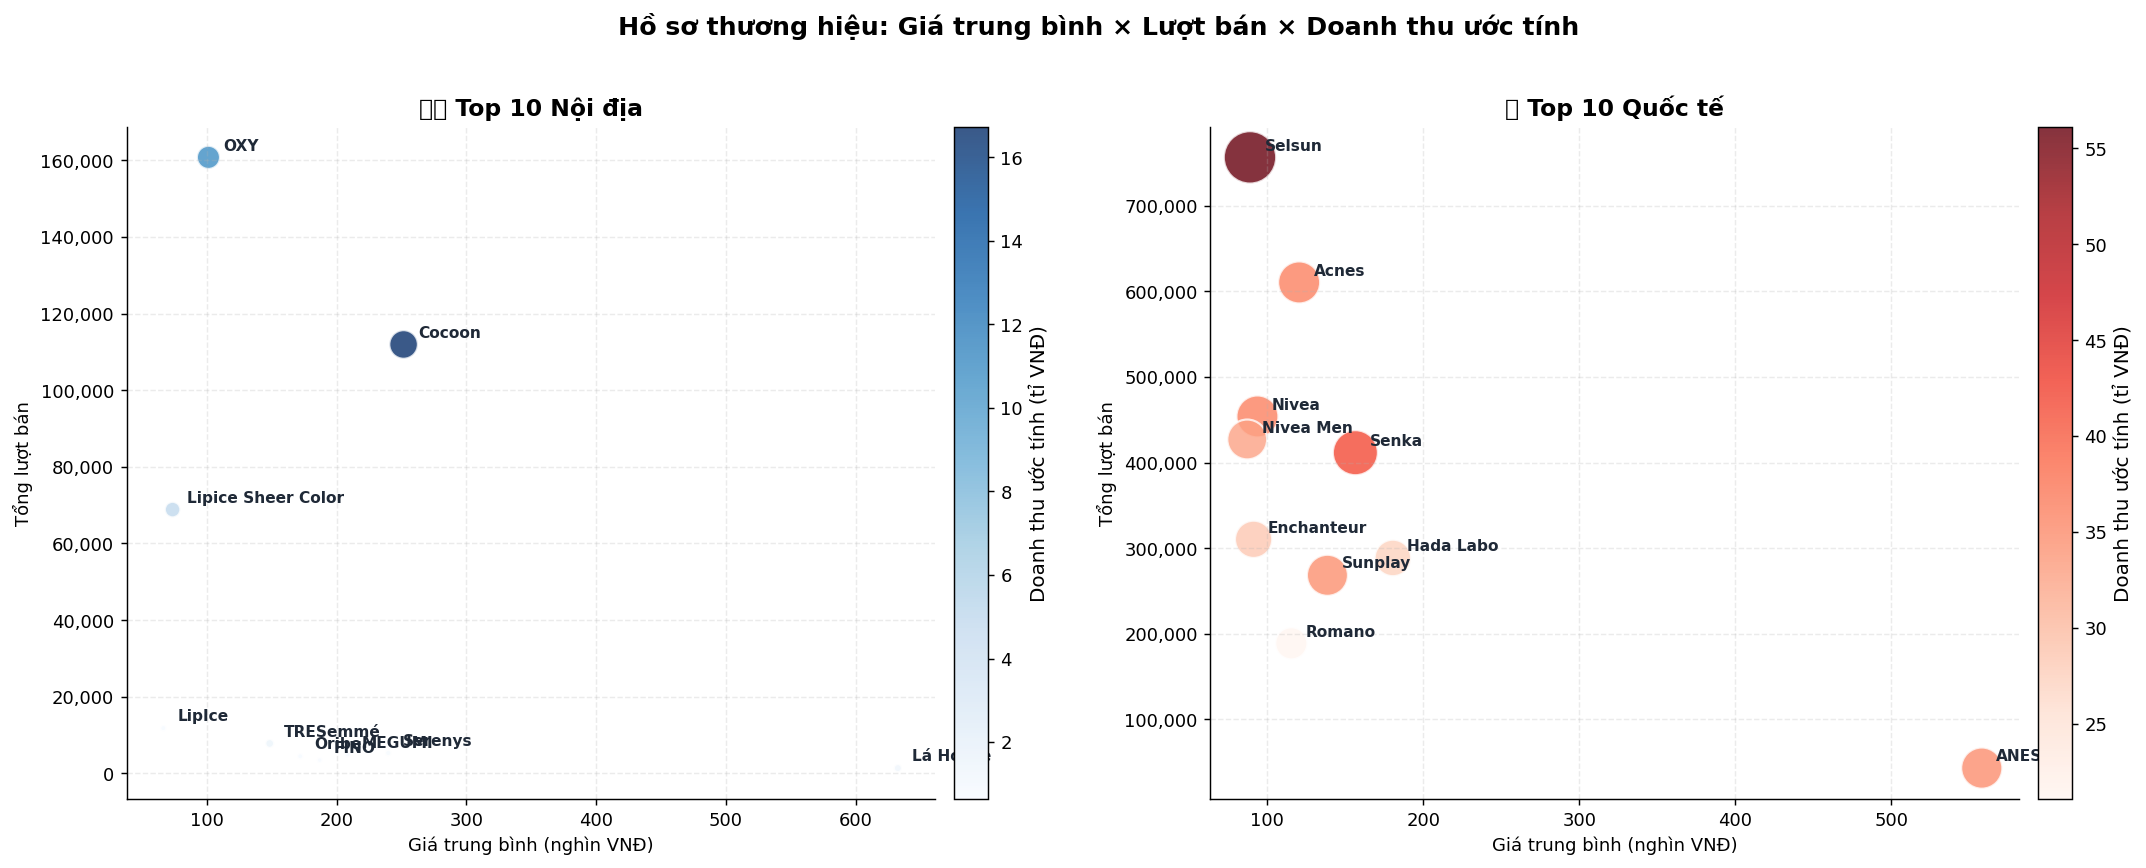

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
fig.suptitle('Hồ sơ thương hiệu: Giá trung bình × Lượt bán × Doanh thu ước tính',
             fontsize=14, fontweight='bold', y=1.02)

for ax, data, color_base, title in [
    (axes[0], top10_vn, C_DOMESTIC, '🇻🇳 Top 10 Nội địa'),
    (axes[1], top10_nn, C_IMPORT,   '🌏 Top 10 Quốc tế')
]:
    sc = ax.scatter(
        data['avg_price'] / 1000,
        data['sold_total'],
        s     = data['revenue_B'] * 15,
        c     = data['revenue_B'],
        cmap  = 'Blues' if color_base == C_DOMESTIC else 'Reds',
        alpha = 0.80,
        edgecolors = 'white',
        linewidths = 1.2
    )
    for _, row in data.iterrows():
        ax.annotate(
            row.name,
            (row['avg_price']/1000, row['sold_total']),
            xytext = (8, 4), textcoords='offset points',
            fontsize=8.5, fontweight='bold', color='#1F2937'
        )
    plt.colorbar(sc, ax=ax, label='Doanh thu ước tính (tỉ VNĐ)', pad=0.02)
    ax.set_xlabel('Giá trung bình (nghìn VNĐ)', fontsize=10)
    ax.set_ylabel('Tổng lượt bán', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../docs/img_mt2_bubble.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.4 Cơ cấu ngành hàng của Top 10 thương hiệu

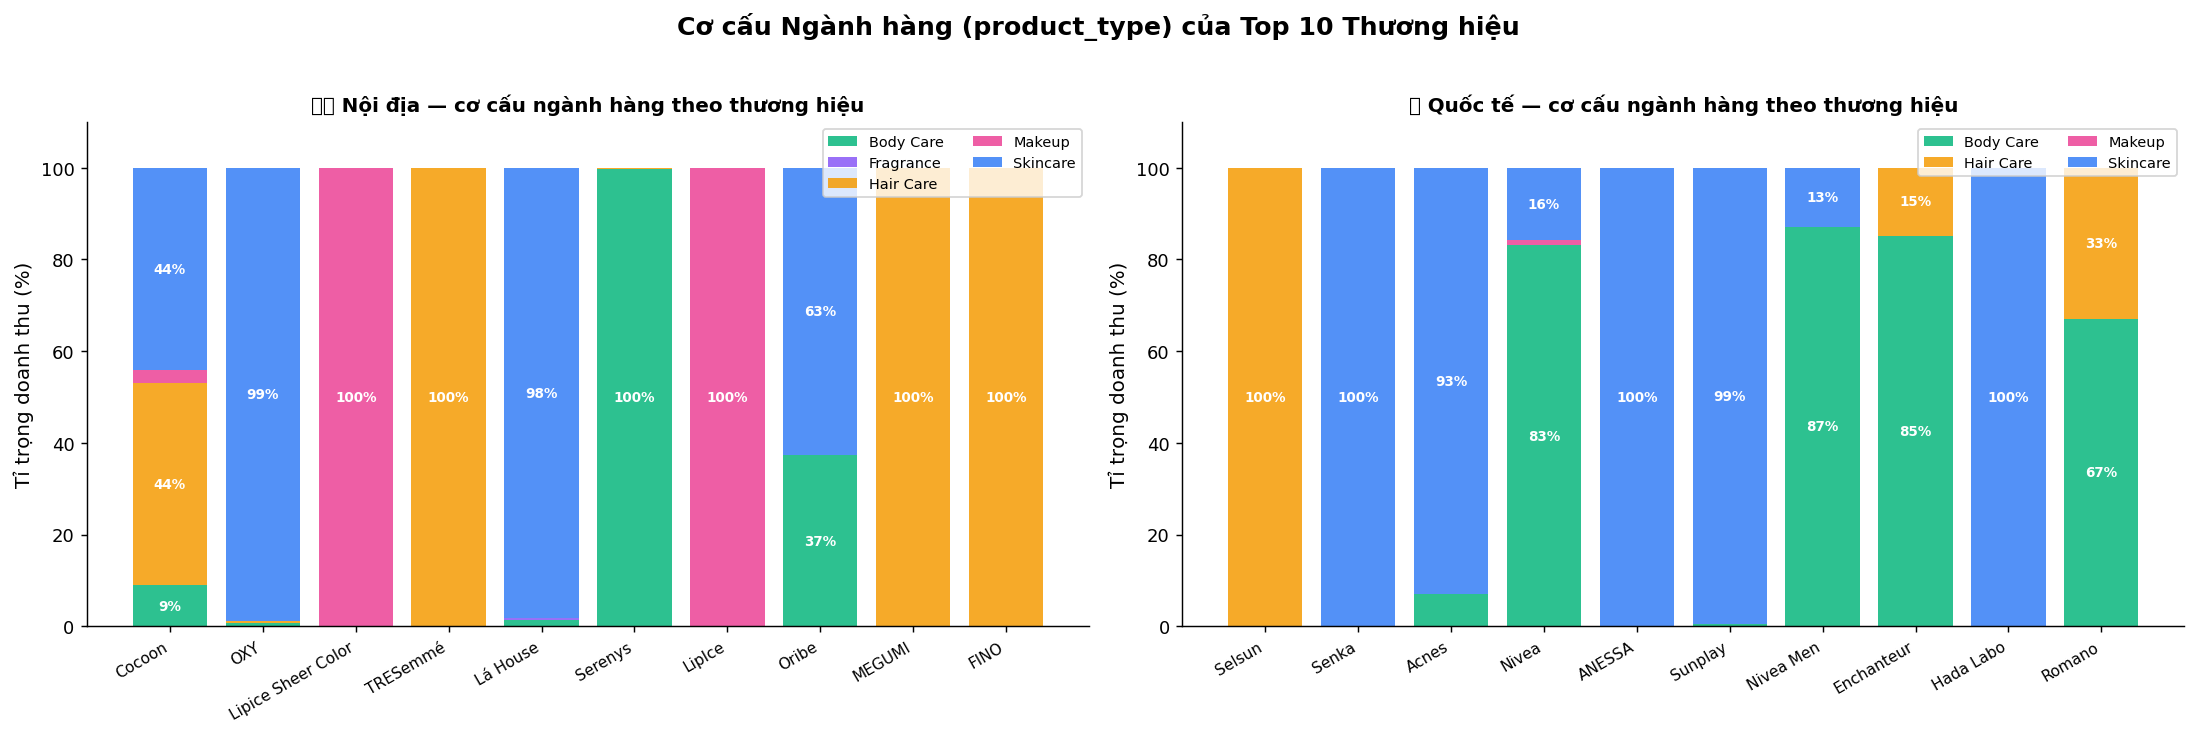

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
fig.suptitle('Cơ cấu Ngành hàng (product_type) của Top 10 Thương hiệu',
             fontsize=14, fontweight='bold', y=1.02)

type_colors = {
    'Skincare'  : '#3B82F6', 'Makeup'    : '#EC4899',
    'Body Care' : '#10B981', 'Hair Care'  : '#F59E0B',
    'Fragrance' : '#8B5CF6', 'Khác'       : '#9CA3AF'
}

for ax, df_sub, top10, title in [
    (axes[0], df_vn, top10_vn, '🇻🇳 Nội địa — cơ cấu ngành hàng theo thương hiệu'),
    (axes[1], df_nn, top10_nn, '🌏 Quốc tế — cơ cấu ngành hàng theo thương hiệu')
]:
    sub = df_sub[df_sub['brand_name'].isin(top10.index)].copy()
    pivot = sub.groupby(['brand_name','product_type'])['estimated_revenue'].sum().unstack(fill_value=0)
    pivot = pivot.loc[top10.index]  # giữ thứ tự top
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

    bottom = np.zeros(len(pivot_pct))
    for ptype in pivot_pct.columns:
        if ptype in type_colors:
            vals = pivot_pct[ptype].values
            ax.bar(range(len(pivot_pct)), vals, bottom=bottom,
                   color=type_colors[ptype], label=ptype, alpha=0.88)
            for i, (v, b) in enumerate(zip(vals, bottom)):
                if v > 8:
                    ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                            fontsize=7.5, fontweight='bold', color='white')
            bottom += vals

    ax.set_xticks(range(len(pivot_pct)))
    ax.set_xticklabels(pivot_pct.index, rotation=30, ha='right', fontsize=8.5)
    ax.set_ylabel('Tỉ trọng doanh thu (%)')
    ax.set_ylim(0, 110)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.grid(False)

plt.tight_layout()
plt.savefig('../docs/img_mt2_type.png', bbox_inches='tight', dpi=150)
plt.show()

### 📝 Nhận xét & Kết luận — Mục tiêu 2

**Phát hiện chính:**

1. **Hàng nội địa có doanh thu ước tính vượt trội** — Selsun dẫn đầu với **~58,8 tỉ VNĐ**, tiếp theo là Sunplay (**~34,5 tỉ**) và Acnes (**~29,2 tỉ**). Đây là những thương hiệu thuộc phân khúc tiêu dùng nhanh với giá thấp – bán số lượng lớn: Selsun 100ml chỉ 84.000 VNĐ nhưng bán được 548.710 lượt.

2. **Chiến lược của Top nội**: Mô hình **Volume-based** (giá thấp, lượt bán cao) là chìa khóa. Selsun, Acnes, Enchanteur đều có giá trung bình dưới 200.000 VNĐ nhưng lượt bán hàng trăm nghìn. Đây là thế mạnh của hàng nội trong phân khúc bình dân đại trà.

3. **Top thương hiệu quốc tế**: Nivea dẫn đầu (**~38,8 tỉ VNĐ**) nhờ danh mục Body Care/khử mùi bán rất chạy (thực chất sản xuất tại Thái Lan). Senka (**~36,4 tỉ**) và Nivea Men (**~30 tỉ**) tiếp theo. Đáng chú ý, Anessa dù có ít lượt bán (36.636) nhưng doanh thu ~27,7 tỉ — phản ánh chiến lược **Premium-based** với giá cao.

4. **Cơ cấu ngành hàng** phản ánh năng lực thương hiệu: Cocoon (nội địa) và Nivea (quốc tế) đều đa dạng hóa ngành hàng, trong khi Selsun tập trung hoàn toàn vào Hair Care — chiến lược chuyên sâu đang mang lại hiệu quả cao.

**Kết luận:** Không có một thương hiệu nội địa nào áp đảo toàn diện thị trường — thành công đến từ định vị rõ ràng (Selsun: trị gàu; Acnes: da mụn) và khai thác tốt phân khúc đại chúng. Các thương hiệu quốc tế cạnh tranh ở phân khúc cao hơn, tạo ra không gian riêng ít va chạm trực tiếp.

---
## 📌 Mục tiêu 3: Phân tích tỷ trọng quốc gia xuất xứ trong nhóm hàng nhập khẩu — Xác định Top 3 đối thủ

### 3.1 Tổng quan tỷ trọng số sản phẩm theo quốc gia

In [18]:
# ── Tổng hợp profile từng quốc gia ──────────────────────────────────────────
country_profile = df_nn.groupby('origin_normalized').agg(
    products   = ('product_id',        'count'),
    revenue    = ('estimated_revenue', 'sum'),
    sold       = ('sold_count',        'sum'),
    brands     = ('brand_name',        'nunique'),
    avg_price  = ('price',             'mean'),
    avg_rating = ('rating',            lambda x: x[x>0].mean() if (x>0).any() else np.nan)
).sort_values('revenue', ascending=False)

country_profile['revenue_B']  = country_profile['revenue']  / 1e9
country_profile['pct_products'] = country_profile['products'] / country_profile['products'].sum() * 100
country_profile['pct_revenue']  = country_profile['revenue']  / country_profile['revenue'].sum()  * 100

top10_countries = country_profile.head(10)
print(top10_countries[['products','pct_products','revenue_B','pct_revenue','sold','brands','avg_price','avg_rating']].round(2).to_string())

                   products  pct_products  revenue_B  pct_revenue     sold  brands   avg_price  avg_rating
origin_normalized                                                                                         
Việt Nam                332          6.31     214.20        51.42  2424570      55   336327.30        4.67
Nhật Bản               1118         21.24      93.94        22.55   584181     158   417794.41        4.68
Thái Lan                191          3.63      73.86        17.73   905223      26   230773.40        4.76
Pháp                    558         10.60       9.92         2.38    46196      65  1113192.45        4.43
Hàn Quốc               1547         29.39       6.40         1.54    21412     218   753192.19        4.71
Mỹ                      347          6.59       4.38         1.05    13814      51  1426021.76        4.64
Ý                       183          3.48       3.38         0.81     3672      33  1493902.67        4.64
Đài Loan                169          

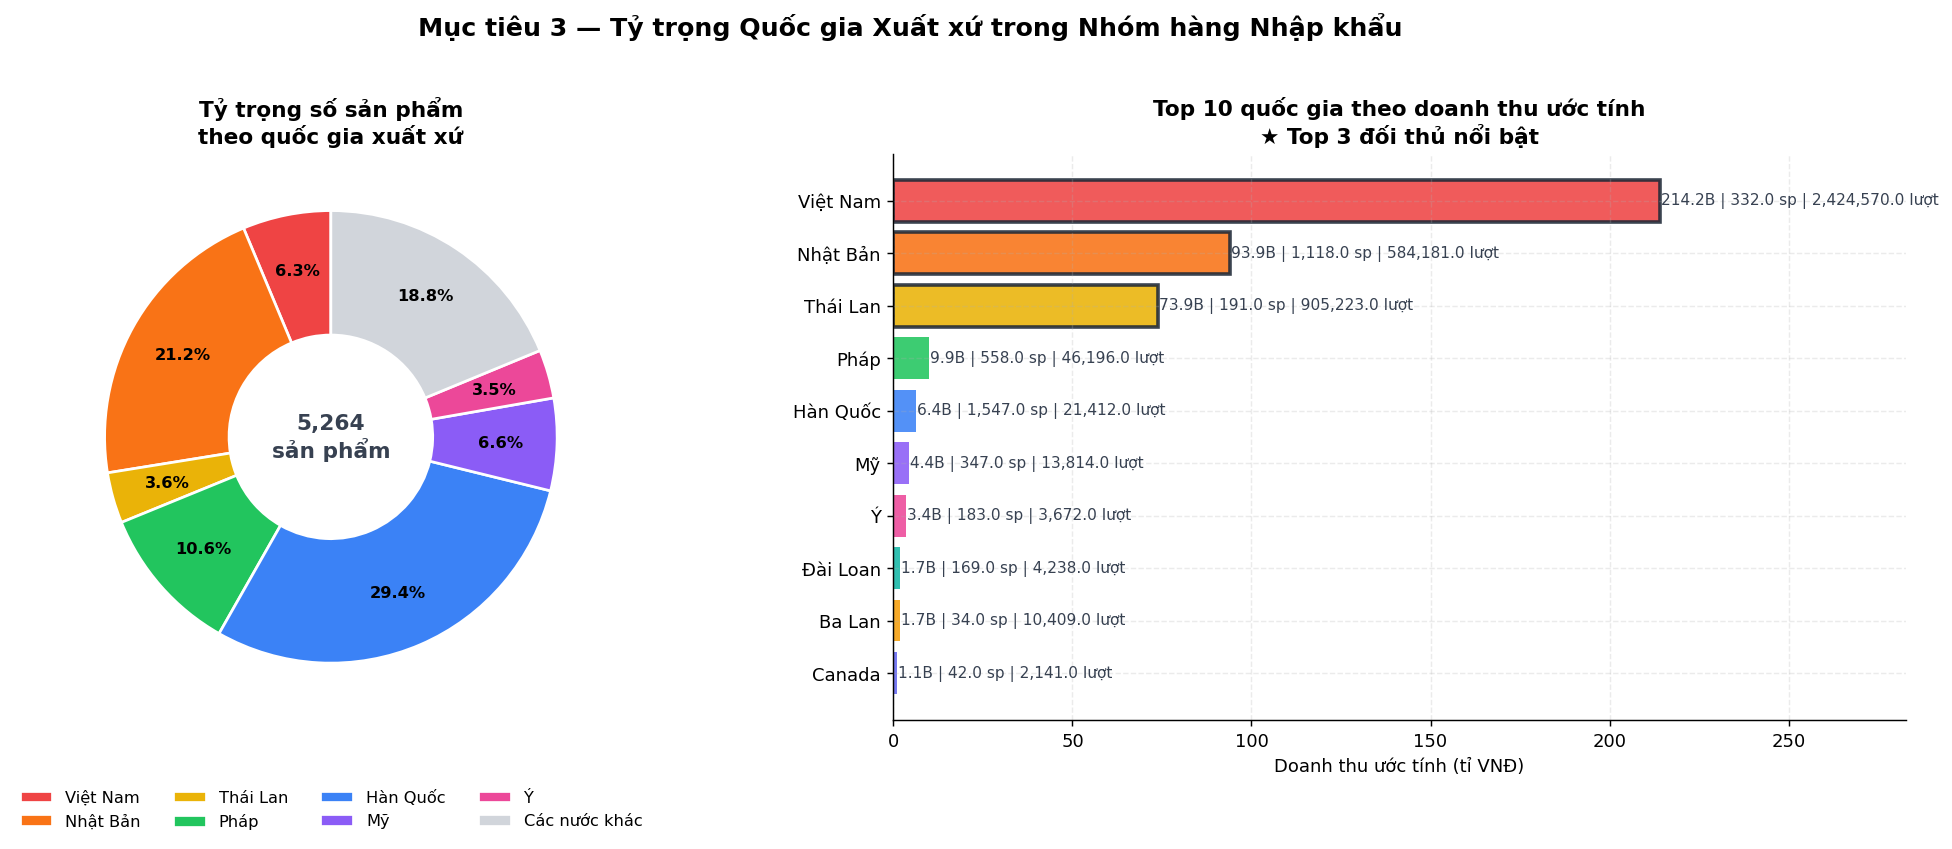

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
fig.suptitle('Mục tiêu 3 — Tỷ trọng Quốc gia Xuất xứ trong Nhóm hàng Nhập khẩu',
             fontsize=14, fontweight='bold', y=1.02)

# ── Biểu đồ 1: Donut — tỷ trọng số sản phẩm ────────────────────────────────
ax1 = axes[0]
top7       = country_profile.head(7)
others_cnt = country_profile.iloc[7:]['products'].sum()
labels7    = list(top7.index) + ['Các nước khác']
values7    = list(top7['products']) + [others_cnt]
colors7    = COUNTRY_COLORS[:7] + ['#D1D5DB']

wedges, texts, autotexts = ax1.pie(
    values7, labels=None, autopct='%1.1f%%',
    colors=colors7, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(9); at.set_fontweight('bold')

ax1.legend(labels7, loc='lower center', bbox_to_anchor=(0.5, -0.22),
           ncol=4, fontsize=9, frameon=False)
ax1.set_title('Tỷ trọng số sản phẩm\ntheo quốc gia xuất xứ', fontweight='bold', fontsize=12)
ax1.text(0, 0, f'{len(df_nn):,}\nsản phẩm', ha='center', va='center',
         fontsize=12, fontweight='bold', color='#374151')

# ── Biểu đồ 2: Horizontal bar — doanh thu theo quốc gia ─────────────────────
ax2 = axes[1]
top10_plot = top10_countries.sort_values('revenue_B', ascending=True)
c_bars = COUNTRY_COLORS[:len(top10_plot)][::-1]
bars   = ax2.barh(top10_plot.index, top10_plot['revenue_B'], color=c_bars, alpha=0.88)

for bar, (idx, row) in zip(bars, top10_plot.iterrows()):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{row["revenue_B"]:.1f}B | {row["products"]:,} sp | {row["sold"]:,} lượt',
             va='center', fontsize=8.5, color='#374151')

# Highlight top 3
top3_names = country_profile.head(3).index.tolist()
for bar, idx in zip(bars, top10_plot.index):
    if idx in top3_names:
        bar.set_edgecolor('#1F2937'); bar.set_linewidth(2)

ax2.set_xlabel('Doanh thu ước tính (tỉ VNĐ)', fontsize=10)
ax2.set_title('Top 10 quốc gia theo doanh thu ước tính\n★ Top 3 đối thủ nổi bật', fontweight='bold', fontsize=12)
ax2.margins(x=0.32)

plt.tight_layout()
plt.savefig('../docs/img_mt3_overview.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.2 Phân tích sâu Top 3 quốc gia đối thủ

In [ ]:
# Top 3 theo doanh thu: Nhật Bản, Thái Lan, Pháp
TOP3 = country_profile.head(3).index.tolist()
print('Top 3 đối thủ theo doanh thu:', TOP3)

# So sánh top3 vs Việt Nam
metrics = {
    'Số sản phẩm'           : 'products',
    'Doanh thu (tỉ VNĐ)'    : 'revenue_B',
    'Tổng lượt bán'         : 'sold',
    'Số thương hiệu'        : 'brands',
    'Giá TB (nghìn VNĐ)'    : 'avg_price',
}

# Tổng hợp Việt Nam
vn_profile = pd.Series({
    'products' : len(df_vn),
    'revenue_B': df_vn['estimated_revenue'].sum() / 1e9,
    'sold'     : df_vn['sold_count'].sum(),
    'brands'   : df_vn['brand_name'].nunique(),
    'avg_price': df_vn['price'].mean() / 1000,
})

compare_df = country_profile.loc[TOP3, ['products','revenue_B','sold','brands','avg_price']].copy()
compare_df['avg_price'] = compare_df['avg_price'] / 1000
compare_df.loc['Việt Nam'] = vn_profile
print()
print(compare_df.round(1).to_string())

Top 3 đối thủ theo doanh thu: ['Nhật Bản', 'Thái Lan', 'Pháp']

                   products  revenue_B       sold  brands  avg_price
origin_normalized                                                   
Nhật Bản             1109.0       88.0   580763.0   158.0      416.2
Thái Lan              190.0       75.2   893304.0    28.0      215.4
Pháp                  572.0        9.8    45989.0    67.0     1096.6
Việt Nam             2340.0      260.3  2764740.0   414.0      349.0


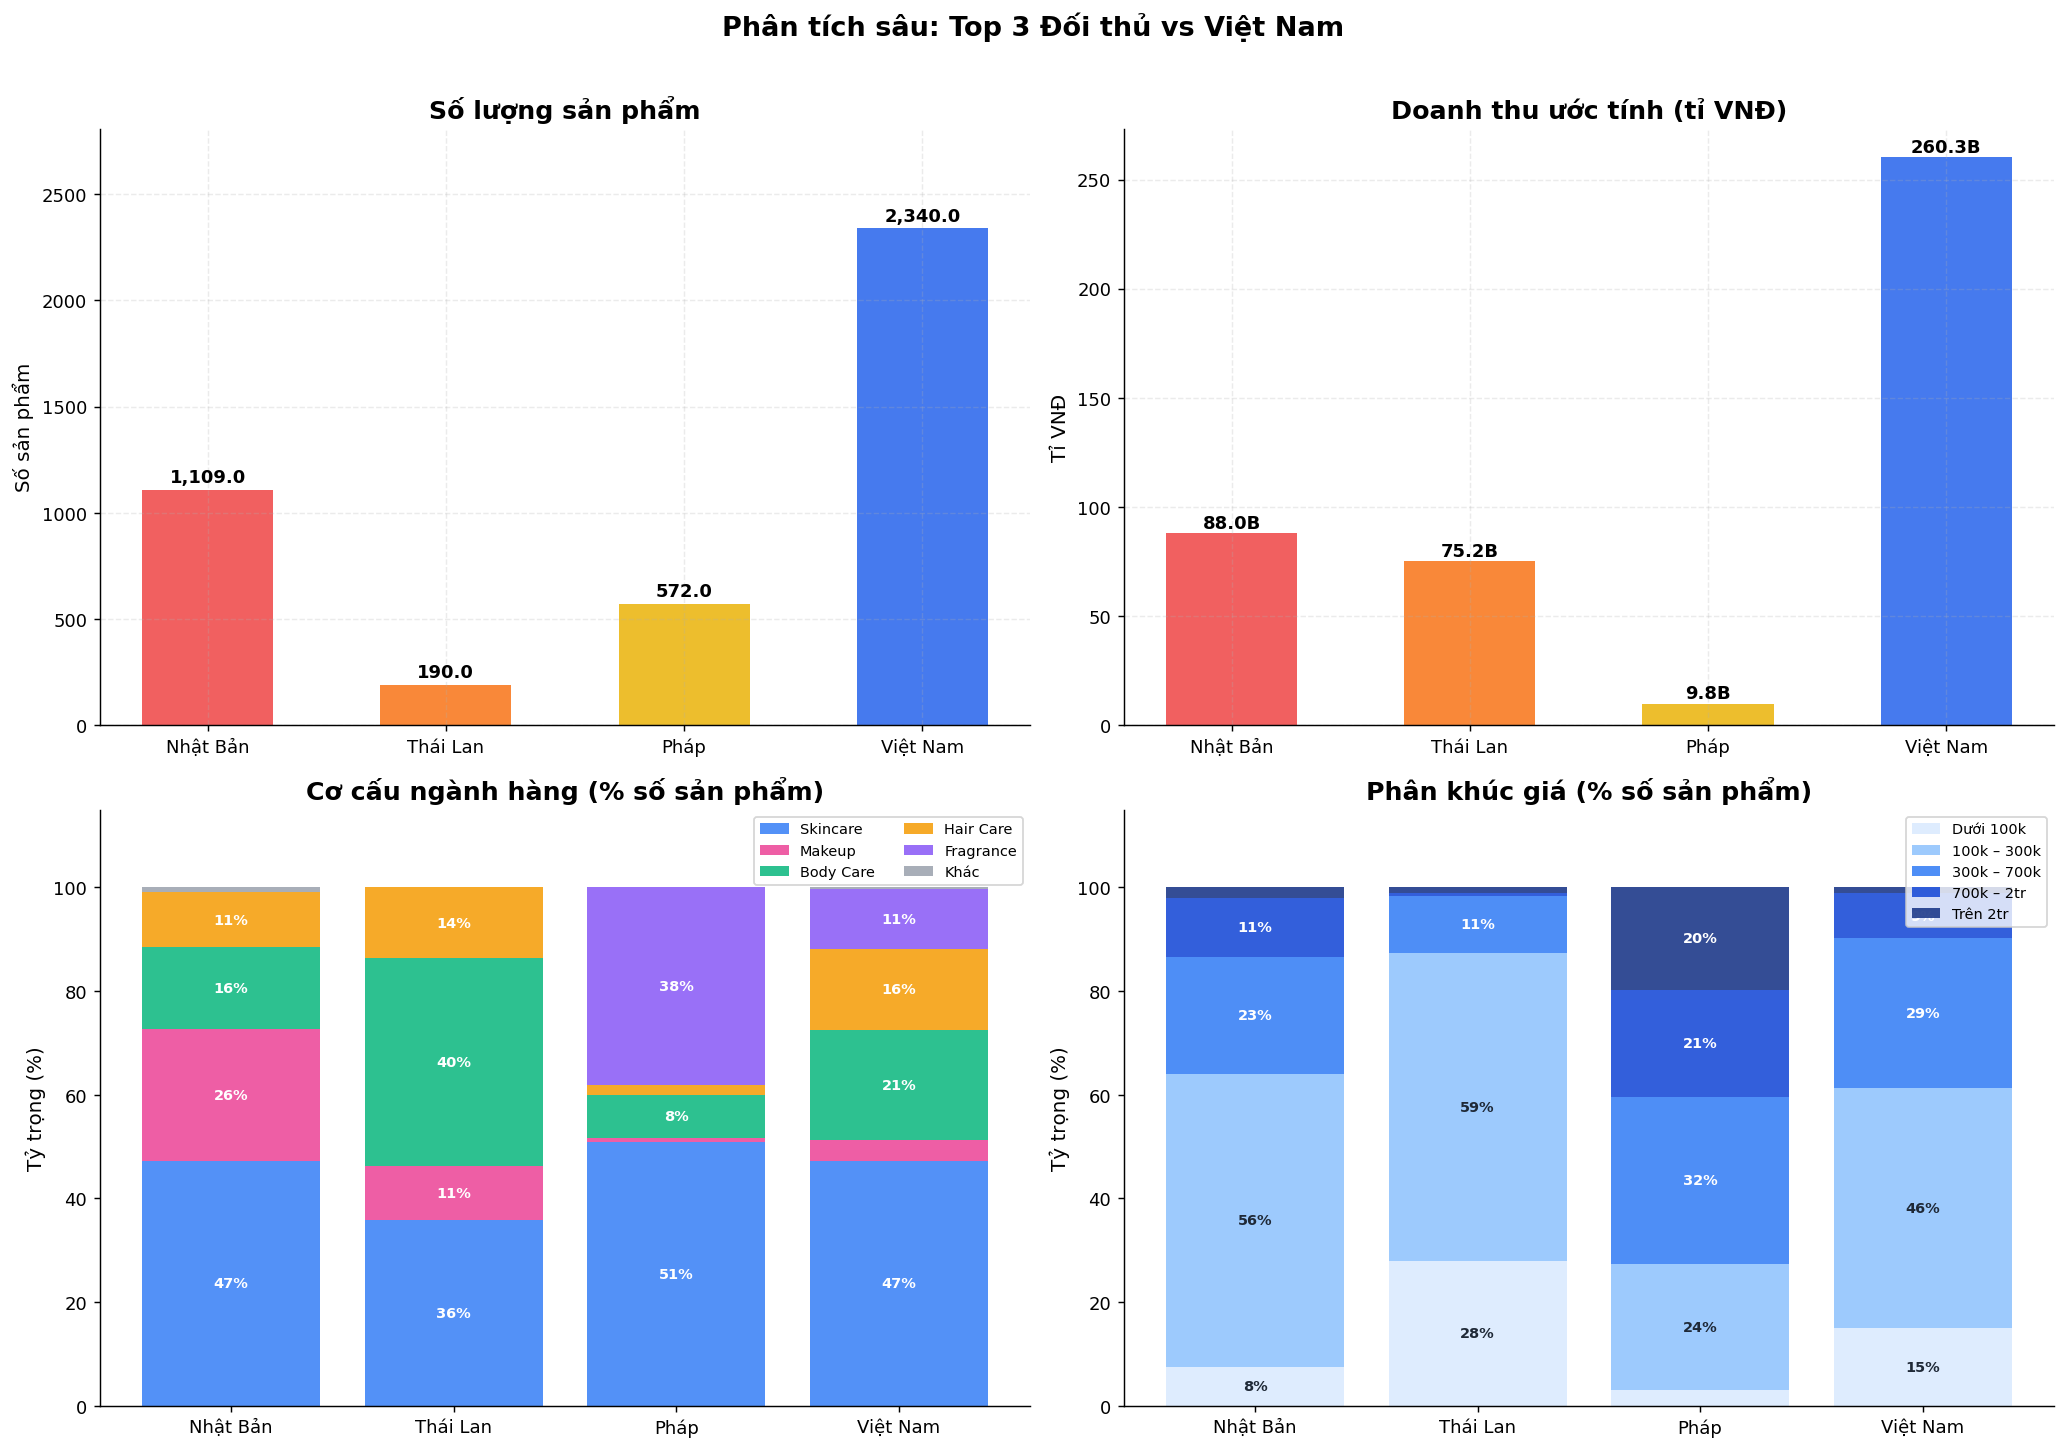

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Phân tích sâu: Top 3 Đối thủ vs Việt Nam',
             fontsize=15, fontweight='bold', y=1.01)

countries_compare = TOP3 + ['Việt Nam']
bar_colors        = ['#EF4444','#F97316','#EAB308','#2563EB']

# ── Plot 1: Số sản phẩm ──────────────────────────────────────────────────────
ax1 = axes[0,0]
vals = compare_df.loc[countries_compare, 'products'].values
bars = ax1.bar(countries_compare, vals, color=bar_colors, alpha=0.85, width=0.55)
for bar, v in zip(bars, vals):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
             f'{v:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.set_title('Số lượng sản phẩm', fontweight='bold')
ax1.set_ylabel('Số sản phẩm')
ax1.set_ylim(0, max(vals)*1.2)

# ── Plot 2: Doanh thu ─────────────────────────────────────────────────────────
ax2 = axes[0,1]
vals2 = compare_df.loc[countries_compare, 'revenue_B'].values
bars2 = ax2.bar(countries_compare, vals2, color=bar_colors, alpha=0.85, width=0.55)
for bar, v in zip(bars2, vals2):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{v:.1f}B', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax2.set_title('Doanh thu ước tính (tỉ VNĐ)', fontweight='bold')
ax2.set_ylabel('Tỉ VNĐ')

# ── Plot 3: Cơ cấu ngành hàng Top3 vs VN (stacked bar) ──────────────────────
ax3 = axes[1,0]
type_colors_3 = {
    'Skincare':'#3B82F6','Makeup':'#EC4899',
    'Body Care':'#10B981','Hair Care':'#F59E0B',
    'Fragrance':'#8B5CF6','Khác':'#9CA3AF'
}
pt_all = []
for c in countries_compare:
    if c == 'Việt Nam':
        sub = df_vn
    else:
        sub = df_nn[df_nn['origin_normalized'] == c]
    pt_cnt = sub.groupby('product_type').size()
    pt_pct = pt_cnt / pt_cnt.sum() * 100
    pt_all.append(pt_pct)

pt_df = pd.DataFrame(pt_all, index=countries_compare).fillna(0)
bottom = np.zeros(len(pt_df))
for ptype, color in type_colors_3.items():
    if ptype in pt_df.columns:
        vals3 = pt_df[ptype].values
        ax3.bar(pt_df.index, vals3, bottom=bottom, color=color, label=ptype, alpha=0.88)
        for i, (v, b) in enumerate(zip(vals3, bottom)):
            if v > 6:
                ax3.text(i, b+v/2, f'{v:.0f}%', ha='center', va='center',
                         fontsize=8, color='white', fontweight='bold')
        bottom += vals3

ax3.set_title('Cơ cấu ngành hàng (% số sản phẩm)', fontweight='bold')
ax3.set_ylabel('Tỷ trọng (%)')
ax3.set_ylim(0, 115)
ax3.legend(loc='upper right', fontsize=8, ncol=2)
ax3.grid(False)

# ── Plot 4: Phân khúc giá theo quốc gia ────────────────────────────────────
ax4 = axes[1,1]
price_data = []
for c in countries_compare:
    if c == 'Việt Nam':
        sub = df_vn
    else:
        sub = df_nn[df_nn['origin_normalized'] == c]
    ps = sub.groupby('price_segment', observed=True).size()
    ps_pct = ps / ps.sum() * 100
    price_data.append(ps_pct)

ps_df = pd.DataFrame(price_data, index=countries_compare).fillna(0)
seg_colors = ['#DBEAFE','#93C5FD','#3B82F6','#1D4ED8','#1E3A8A']
bottom4 = np.zeros(len(ps_df))
for seg, color in zip(price_order, seg_colors):
    if seg in ps_df.columns:
        v4 = ps_df[seg].values
        ax4.bar(ps_df.index, v4, bottom=bottom4, color=color, label=seg, alpha=0.9)
        for i, (v, b) in enumerate(zip(v4, bottom4)):
            if v > 6:
                ax4.text(i, b+v/2, f'{v:.0f}%', ha='center', va='center',
                         fontsize=8, color='white' if color in ['#3B82F6','#1D4ED8','#1E3A8A'] else '#1F2937',
                         fontweight='bold')
        bottom4 += v4

ax4.set_title('Phân khúc giá (% số sản phẩm)', fontweight='bold')
ax4.set_ylabel('Tỷ trọng (%)')
ax4.set_ylim(0, 115)
ax4.legend(loc='upper right', fontsize=8, ncol=1)
ax4.grid(False)

plt.tight_layout()
plt.savefig('../docs/img_mt3_top3.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.3 Radar chart — Hồ sơ đa chiều Top 3 vs Việt Nam

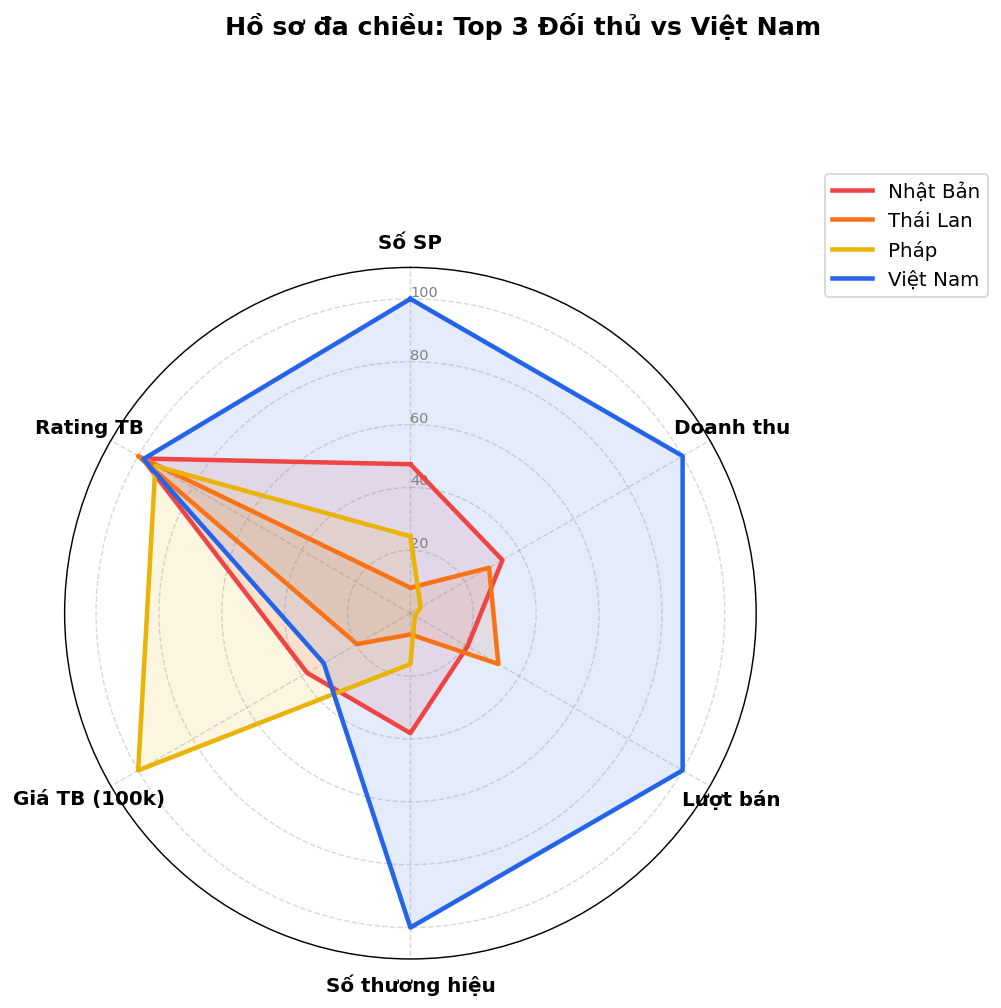

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Hồ sơ đa chiều: Top 3 Đối thủ vs Việt Nam',
             fontsize=14, fontweight='bold', y=1.02)

# Chuẩn bị metrics (normalize 0-100)
radar_data = {}
for c in countries_compare:
    if c == 'Việt Nam':
        sub = df_vn
    else:
        sub = df_nn[df_nn['origin_normalized'] == c]
    radar_data[c] = {
        'Số SP'         : len(sub),
        'Doanh thu'     : sub['estimated_revenue'].sum() / 1e9,
        'Lượt bán'      : sub['sold_count'].sum() / 1000,
        'Số thương hiệu': sub['brand_name'].nunique(),
        'Giá TB (100k)' : sub['price'].mean() / 100000,
        'Rating TB'     : sub[sub['rating']>0]['rating'].mean() if (sub['rating']>0).any() else 0,
    }

radar_df = pd.DataFrame(radar_data).T
radar_norm = radar_df / radar_df.max() * 100  # normalize

categories = list(radar_norm.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rlabel_position(0)
plt.xticks(angles[:-1], categories, size=11, fontweight='bold')
plt.yticks([20,40,60,80,100], ['20','40','60','80','100'], size=8, color='grey')
plt.ylim(0, 110)

plot_colors_radar = ['#EF4444','#F97316','#EAB308','#2563EB']
for (country, row), color in zip(radar_norm.iterrows(), plot_colors_radar):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=country, color=color)
    ax.fill(angles, values, alpha=0.12, color=color)

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.grid(color='grey', alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/img_mt3_radar.png', bbox_inches='tight', dpi=150)
plt.show()

### 📝 Nhận xét & Kết luận — Mục tiêu 3

**Phát hiện chính:**

1. **Hàn Quốc chiếm đa số về số sản phẩm** (1.530 sp, 31,1% tổng hàng nhập khẩu), nhưng chỉ đứng thứ 4 về doanh thu ước tính (~6,8 tỉ VNĐ). Lý do: hàng Hàn Quốc tập trung vào Skincare phân khúc cao nhưng lượt bán thực tế còn thấp (avg sold: 15 lượt/sản phẩm). Hàn Quốc là đối thủ về **đa dạng sản phẩm** nhưng chưa dẫn đầu về **thực lực doanh thu**.

2. **Nhật Bản là đối thủ số 1 toàn diện** (doanh thu ~88 tỉ VNĐ, 580.763 lượt bán). Chiến thắng nhờ Senka và Hada Labo nắm chắc phân khúc chăm sóc da 100k–300k — đúng "sweet spot" của người tiêu dùng Việt. Nhật Bản cạnh tranh trực tiếp với hàng nội cả về giá lẫn danh mục Skincare.

3. **Thái Lan là bất ngờ lớn nhất** — đứng thứ 2 về doanh thu (~75,2 tỉ VNĐ) và số 1 về lượt bán (893.304 lượt), vượt xa dự kiến. Toàn bộ doanh thu đến từ thương hiệu Nivea và Nivea Men (sản xuất tại Thái Lan) — phân khúc khử mùi/Body Care đại trà, cạnh tranh trực tiếp với Romano và Enchanteur của nội địa.

4. **Pháp đứng thứ 3** (~9,8 tỉ VNĐ) nhờ Fragrance (chiếm 38% sản phẩm Pháp) — phân khúc mà hàng nội địa gần như không có mặt. Đây là đối thủ cạnh tranh ở **phân khúc cao cấp**, không va chạm trực tiếp với mass market Việt.

5. **Radar chart** xác nhận: Việt Nam vượt trội về số thương hiệu và lượt bán (volume), Nhật dẫn đầu doanh thu, Thái Lan đứng đầu lượt bán tuyệt đối nhờ Nivea.

**Kết luận — Top 3 đối thủ cạnh tranh trực tiếp với mỹ phẩm Việt Nam:**

| Hạng | Quốc gia | Chiến trường chính | Mức độ cạnh tranh |
|------|----------|-------------------|-------------------|
| 🥇 | **Nhật Bản** | Skincare đại chúng (100k–500k) | ⚡ Trực tiếp, cao nhất |
| 🥈 | **Thái Lan** | Body Care / Khử mùi đại trà | ⚡ Trực tiếp, volume lớn |
| 🥉 | **Pháp** | Fragrance cao cấp (>1tr) | ↕ Gián tiếp, phân khúc khác |

---
## 🏁 Tổng kết — Giải đáp Bài toán Chung

> **Bài toán:** Phân tích sự ưu tiên của người tiêu dùng Việt Nam đối với mỹ phẩm trong và ngoài nước trên Tiki (tháng 3/2026)

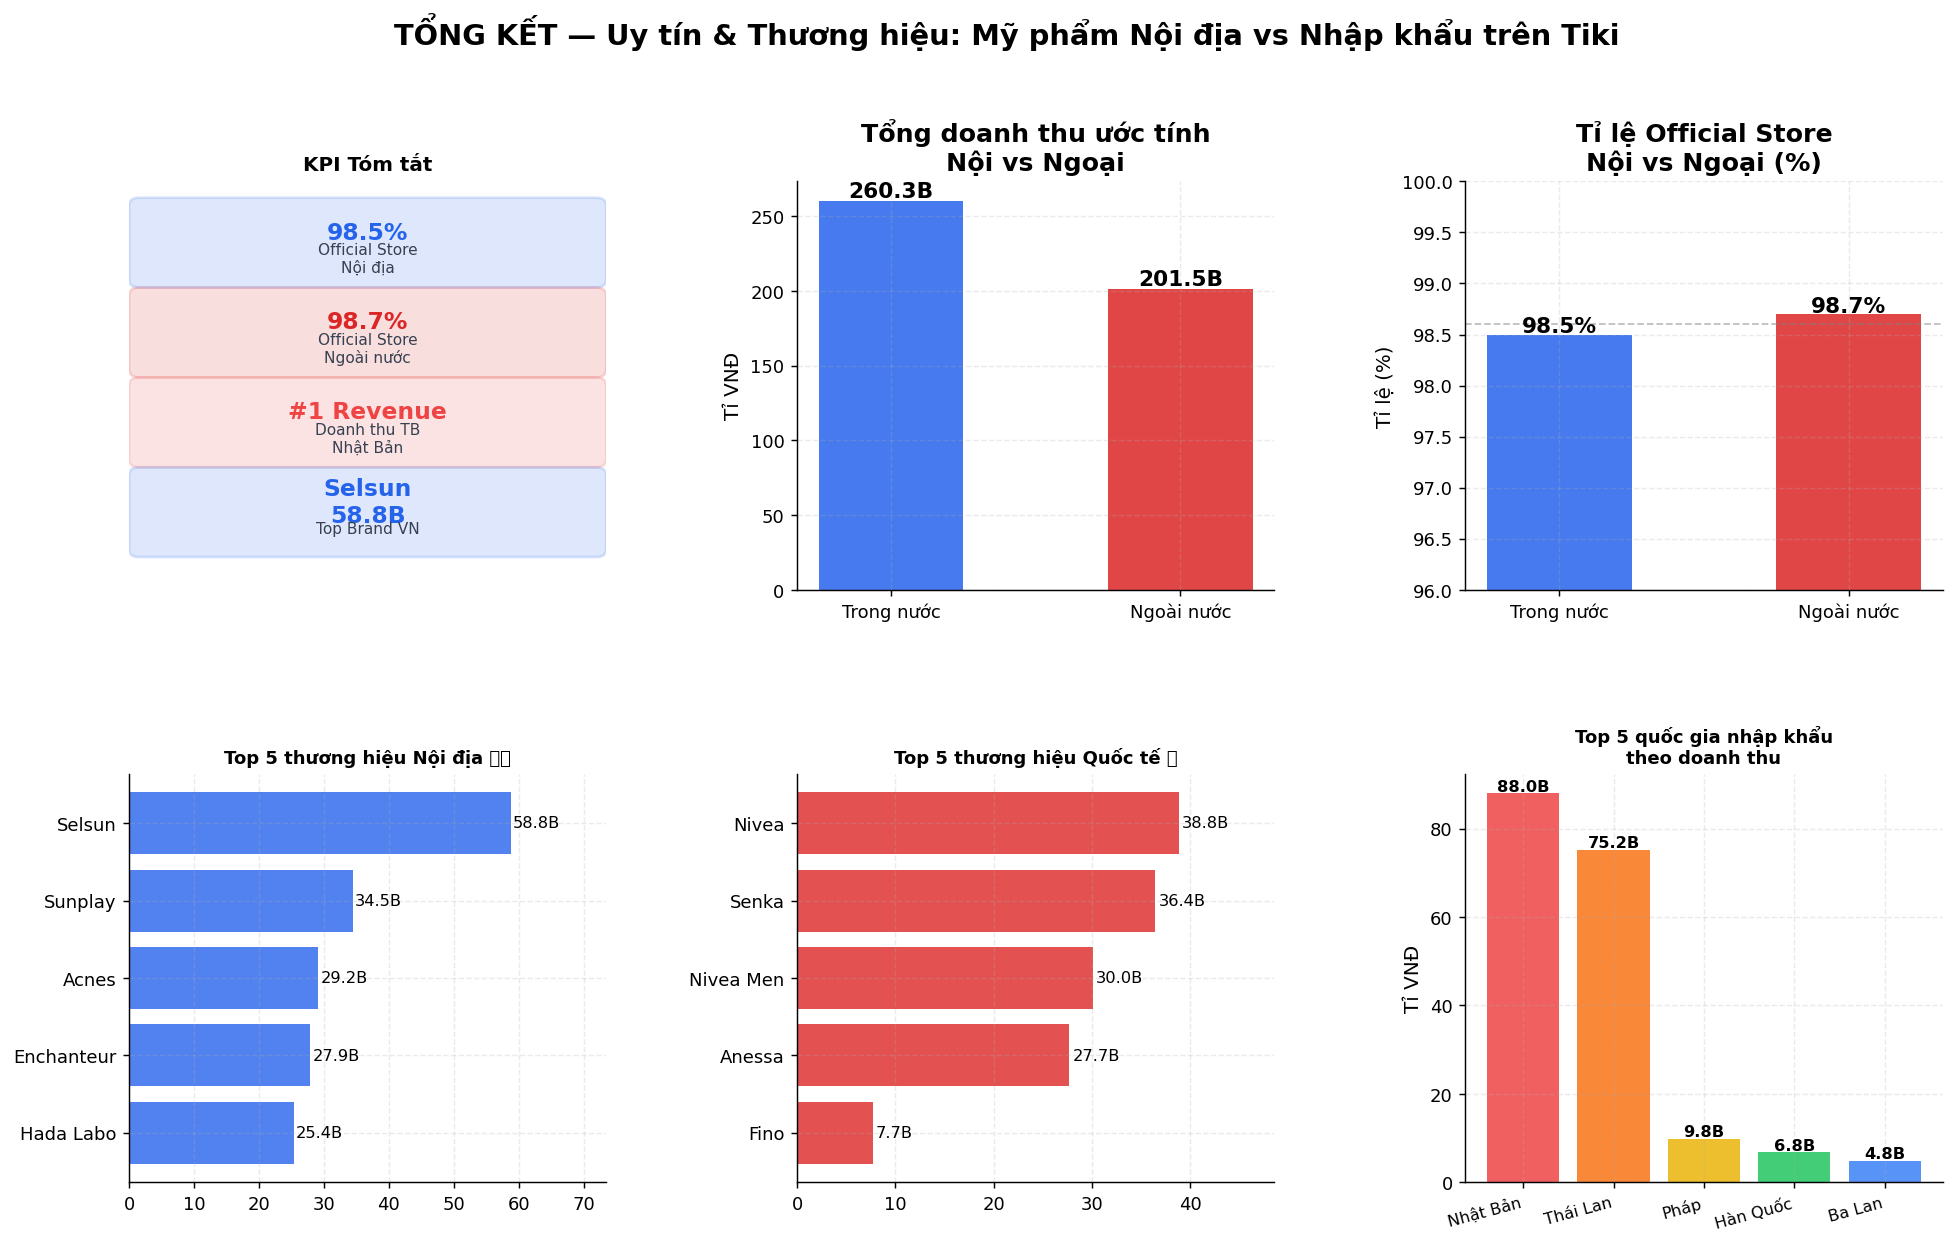

In [ ]:
# ── Dashboard tổng kết ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.suptitle('TỔNG KẾT — Uy tín & Thương hiệu: Mỹ phẩm Nội địa vs Nhập khẩu trên Tiki',
             fontsize=16, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.4)

# Panel 1: KPI cards summary (text)
ax_kpi = fig.add_subplot(gs[0, 0])
ax_kpi.axis('off')
kpi_text = [
    ('Official Store\nNội địa',   '98.5%', C_DOMESTIC),
    ('Official Store\nNgoài nước','98.7%', C_IMPORT),
    ('Doanh thu TB\nNhật Bản',    '#1 Revenue', '#EF4444'),
    ('Top Brand VN',              'Selsun\n58.8B', C_DOMESTIC),
]
for i, (label, value, color) in enumerate(kpi_text):
    y_pos = 0.85 - i * 0.22
    ax_kpi.add_patch(mpatches.FancyBboxPatch((0.02, y_pos-0.09), 0.96, 0.18,
        boxstyle='round,pad=0.02', facecolor=color, alpha=0.15, edgecolor=color, linewidth=1.5))
    ax_kpi.text(0.5, y_pos+0.025, value, ha='center', va='center', fontsize=13,
                fontweight='bold', color=color, transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, y_pos-0.04, label, ha='center', va='center', fontsize=8.5,
                color='#374151', transform=ax_kpi.transAxes)
ax_kpi.set_xlim(0,1); ax_kpi.set_ylim(0,1)
ax_kpi.set_title('KPI Tóm tắt', fontweight='bold', fontsize=11)

# Panel 2: Tổng doanh thu nội vs ngoại
ax2 = fig.add_subplot(gs[0, 1])
total_rev = [df_vn['estimated_revenue'].sum()/1e9, df_nn['estimated_revenue'].sum()/1e9]
bars2 = ax2.bar(['Trong nước', 'Ngoài nước'], total_rev, color=[C_DOMESTIC, C_IMPORT], alpha=0.85, width=0.5)
for bar, v in zip(bars2, total_rev):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'{v:.1f}B',
             ha='center', fontweight='bold', fontsize=12)
ax2.set_ylabel('Tỉ VNĐ'); ax2.set_title('Tổng doanh thu ước tính\nNội vs Ngoại', fontweight='bold')

# Panel 3: Tỉ lệ Official Store theo origin
ax3 = fig.add_subplot(gs[0, 2])
off_rates = [98.5, 98.7]
ax3.bar(['Trong nước', 'Ngoài nước'], off_rates, color=[C_DOMESTIC, C_IMPORT], alpha=0.85, width=0.5)
ax3.set_ylim(96, 100)
for i, v in enumerate(off_rates):
    ax3.text(i, v+0.02, f'{v}%', ha='center', fontweight='bold', fontsize=12)
ax3.set_ylabel('Tỉ lệ (%)')
ax3.set_title('Tỉ lệ Official Store\nNội vs Ngoại (%)', fontweight='bold')
ax3.axhline(y=98.6, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Panel 4: Top 5 brands nội
ax4 = fig.add_subplot(gs[1, 0])
t5_vn = top10_vn.head(5)
ax4.barh(t5_vn.index[::-1], t5_vn['revenue_B'][::-1], color=C_DOMESTIC, alpha=0.8)
for i, (idx, row) in enumerate(t5_vn[::-1].iterrows()):
    ax4.text(row['revenue_B']+0.3, i, f"{row['revenue_B']:.1f}B", va='center', fontsize=9)
ax4.set_title('Top 5 thương hiệu Nội địa 🇻🇳', fontweight='bold', fontsize=10)
ax4.margins(x=0.25)

# Panel 5: Top 5 brands ngoại
ax5 = fig.add_subplot(gs[1, 1])
t5_nn = top10_nn.head(5)
ax5.barh(t5_nn.index[::-1], t5_nn['revenue_B'][::-1], color=C_IMPORT, alpha=0.8)
for i, (idx, row) in enumerate(t5_nn[::-1].iterrows()):
    ax5.text(row['revenue_B']+0.3, i, f"{row['revenue_B']:.1f}B", va='center', fontsize=9)
ax5.set_title('Top 5 thương hiệu Quốc tế 🌏', fontweight='bold', fontsize=10)
ax5.margins(x=0.25)

# Panel 6: Top 3 countries revenue
ax6 = fig.add_subplot(gs[1, 2])
top5c = country_profile.head(5)
ax6.bar(top5c.index, top5c['revenue_B'], color=COUNTRY_COLORS[:5], alpha=0.85)
for i, (idx, row) in enumerate(top5c.iterrows()):
    ax6.text(i, row['revenue_B']+0.5, f'{row["revenue_B"]:.1f}B', ha='center', fontsize=9, fontweight='bold')
ax6.set_xticklabels(top5c.index, rotation=15, ha='right', fontsize=9)
ax6.set_ylabel('Tỉ VNĐ')
ax6.set_title('Top 5 quốc gia nhập khẩu\ntheo doanh thu', fontweight='bold', fontsize=10)

plt.savefig('../docs/img_summary.png', bbox_inches='tight', dpi=150)
plt.show()

## 📋 Kết luận tổng thể

Qua 3 mục tiêu phân tích về **Uy tín & Thương hiệu**, bức tranh thị trường mỹ phẩm trên Tiki tháng 3/2026 hiện rõ như sau:

**1. Về uy tín kênh phân phối (MT1):**
Tỉ lệ Official Store gần như đồng đều giữa hàng nội (98,5%) và ngoại (98,7%), cho thấy Tiki đã trở thành sân chơi bình đẳng. Kênh chính hãng mang lại lợi thế thực sự về lượt bán — Official Store vận hành hiệu quả hơn Non-Official hàng chục lần.

**2. Về thương hiệu dẫn dắt thị trường (MT2):**
Hàng nội địa dẫn đầu nhờ chiến lược **volume-based** (giá thấp, bán nhiều) — Selsun, Acnes, Enchanteur. Hàng quốc tế cạnh tranh bằng **brand premium** — Anessa đạt 27,7 tỉ chỉ với 36.636 lượt bán. Hai chiến lược không triệt tiêu nhau mà cùng tồn tại trong các phân khúc riêng.

**3. Về đối thủ cạnh tranh quốc tế (MT3):**
**Nhật Bản** là mối đe dọa số 1 (88 tỉ VNĐ doanh thu) do cạnh tranh trực tiếp ở phân khúc Skincare đại chúng. **Thái Lan** (chủ yếu là Nivea) là đối thủ bất ngờ trong Body Care. **Hàn Quốc** nhiều sản phẩm nhất nhưng chưa chuyển đổi thành doanh thu hiệu quả — đây là tiềm năng nguy hiểm trong tương lai.

> **Hàm ý chiến lược:** Thương hiệu Việt nên tập trung phòng thủ phân khúc 100k–300k trước Nhật Bản và Thái Lan, đồng thời nâng dần phân khúc cao để tránh bị kẹp giữa hàng Hàn Quốc đang mở rộng và hàng Pháp cao cấp.